# Dasheng — Glasgow Age Group Classification

Tests whether pretrained audio spectrogram representations encode **age group** information from micro-Doppler radar signatures.

**Protocol:**
1. Extract per-spectrogram embeddings with `dasheng_base_spectrogram` (frozen)
2. **Exclude activity 6 (Falling)** — only performed by young subjects, direct age confound
3. **Mean-pool per subject** across remaining recordings (activities 1–5 × repetitions)
4. Binarise age at a configurable cutoff → Young vs Elderly
5. Leave-one-subject-out cross-validation (LOOCV)
6. Probes: **k-NN** and **Logistic regression**

---

> ⚠️ **Confound warning:** The young/elderly split coincides almost perfectly with a dataset split
> (D01–D05 = young cohort, D06–D07 = elderly cohort). These sub-datasets were collected at different
> times and potentially with different hardware/conditions. A classifier that performs well here
> **cannot be assumed to be detecting age** — it may be detecting dataset-level noise
> (radar calibration, environment, session protocol). Results should be interpreted with this in mind.

## 1. Imports & configuration

In [1]:
import sys
import re
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

print(f"torch : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

torch : 2.10.0+cu130
CUDA available: True
Using device: cuda


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
REPO_ROOT    = Path(".").resolve()
GLASGOW_ROOT = REPO_ROOT / "data" / "Glasgow"
METADATA_CSV = GLASGOW_ROOT / "metadata.csv"

# ── Age binarisation ───────────────────────────────────────────────────────
# Subjects with age < AGE_CUTOFF → "Young", >= AGE_CUTOFF → "Elderly"
AGE_CUTOFF = 60

# ── Model ──────────────────────────────────────────────────────────────────
MODEL_PATH = None   # set to "/path/to/dasheng_base.pt" to skip download

# ── Preprocessing ──────────────────────────────────────────────────────────
USE_LOG1P = True

# ── k-NN ───────────────────────────────────────────────────────────────────
KNN_K = 5

# ── Logistic regression ────────────────────────────────────────────────────
LR_C        = 1.0
LR_MAX_ITER = 1000

assert GLASGOW_ROOT.exists(), f"Glasgow data not found: {GLASGOW_ROOT}"
assert METADATA_CSV.exists(), f"metadata.csv not found: {METADATA_CSV}"
print("Paths OK")

Paths OK


## 2. Load model

In [3]:
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dasheng import dasheng_base_spectrogram

model = dasheng_base_spectrogram(path=MODEL_PATH)
model = model.eval().to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Loaded dasheng_base_spectrogram  ({n_params/1e6:.1f}M parameters)")

Loaded dasheng_base_spectrogram  (85.4M parameters)


## 3. Load metadata & inspect age distribution

In [4]:
meta = pd.read_csv(METADATA_CSV)
meta = meta.dropna(subset=["age"])
meta["age"] = meta["age"].astype(int)
meta["age_group"] = (meta["age"] >= AGE_CUTOFF).astype(int)  # 0=Young, 1=Elderly

n_young   = (meta["age_group"] == 0).sum()
n_elderly = (meta["age_group"] == 1).sum()
chance    = max(n_young, n_elderly) / len(meta)

print(f"{len(meta)} subjects with known age")
print(f"Cutoff: {AGE_CUTOFF} yrs  →  Young: {n_young}  |  Elderly: {n_elderly}")
print(f"Majority-class baseline: {chance*100:.1f}%")

103 subjects with known age
Cutoff: 60 yrs  →  Young: 78  |  Elderly: 25
Majority-class baseline: 75.7%


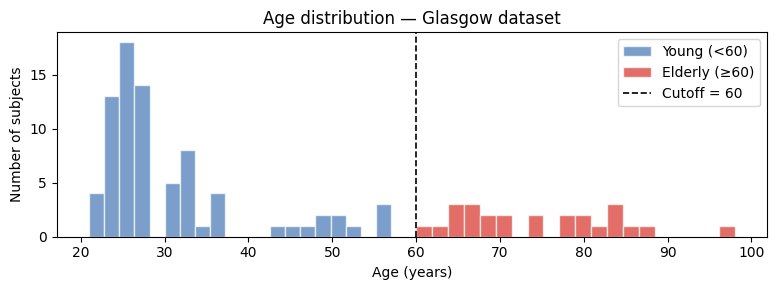

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(meta[meta["age_group"]==0]["age"], bins=20, alpha=0.7, label=f"Young (<{AGE_CUTOFF})",   color="#4575b4", edgecolor="white")
ax.hist(meta[meta["age_group"]==1]["age"], bins=20, alpha=0.7, label=f"Elderly (≥{AGE_CUTOFF})", color="#d73027", edgecolor="white")
ax.axvline(AGE_CUTOFF, color="black", linestyle="--", linewidth=1.2, label=f"Cutoff = {AGE_CUTOFF}")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of subjects")
ax.set_title("Age distribution — Glasgow dataset")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Feature extraction (per spectrogram)

In [6]:
def parse_subject_key(filepath: Path) -> str | None:
    """Extract 'D{dataset:02d}P{participant:02d}' from filename.
    Filename format: D{DD}_{activity}P{PP}A{AA}R{RR}.npy
    """
    m = re.match(r'D(\d+)_\d+P(\d+)', filepath.stem)
    if m:
        return f"D{int(m.group(1)):02d}P{int(m.group(2)):02d}"
    return None


@torch.inference_mode()
def extract_features(
    model: torch.nn.Module,
    files: list[Path],
    use_log1p: bool = True,
    device: torch.device = torch.device("cpu"),
) -> np.ndarray:
    features = []
    for filepath in tqdm(files, desc="Extracting features"):
        spec = np.ascontiguousarray(np.load(filepath), dtype=np.float32)
        if use_log1p:
            spec = np.log1p(spec)
        x = torch.from_numpy(spec).unsqueeze(0).to(device)  # (1, F, T)
        out = model(x)                                        # (1, N_patches, D)
        features.append(out.mean(dim=1).squeeze(0).cpu().float().numpy())
    return np.stack(features)


# Exclude activity 6 (Falling) — only performed by young subjects, direct age confound
all_files = sorted(p for p in GLASGOW_ROOT.glob("*/*.npy") if p.parent.name != "6")
print(f"Found {len(all_files)} spectrograms (activities 1–5, Falling excluded)")

features_all = extract_features(model, all_files, USE_LOG1P, DEVICE)
print(f"Features shape: {features_all.shape}")

Found 1883 spectrograms (activities 1–5, Falling excluded)


Extracting features:   0%|          | 0/1883 [00:00<?, ?it/s]

Extracting features: 100%|██████████| 1883/1883 [00:29<00:00, 64.35it/s]

Features shape: (1883, 768)


## 5. Subject-level aggregation

Mean-pool all embeddings belonging to the same subject. This averages out activity-specific variation, leaving the person-specific signal.

In [7]:
subject_feats: dict[str, list[np.ndarray]] = defaultdict(list)
for path, feat in zip(all_files, features_all):
    key = parse_subject_key(path)
    if key:
        subject_feats[key].append(feat)

valid_keys = set(meta["subject_key"])

subject_keys, X_subjects, y_groups = [], [], []
for key, feats in sorted(subject_feats.items()):
    if key not in valid_keys:
        continue
    row = meta[meta["subject_key"] == key]
    subject_keys.append(key)
    X_subjects.append(np.mean(feats, axis=0))
    y_groups.append(int(row["age_group"].values[0]))

X_subjects = np.stack(X_subjects)
y_groups   = np.array(y_groups)   # 0=Young, 1=Elderly

print(f"{len(subject_keys)} subjects")
print(f"Young: {(y_groups==0).sum()}  |  Elderly: {(y_groups==1).sum()}")

103 subjects
Young: 78  |  Elderly: 25


## 6. Leave-one-subject-out cross-validation

In [8]:
N = len(subject_keys)
knn_preds = np.zeros(N, dtype=int)
lr_preds  = np.zeros(N, dtype=int)
knn_proba = np.zeros(N)
lr_proba  = np.zeros(N)

for i in range(N):
    train_mask = np.ones(N, dtype=bool)
    train_mask[i] = False

    X_train, y_train = X_subjects[train_mask], y_groups[train_mask]
    X_test            = X_subjects[~train_mask]

    knn_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsClassifier(n_neighbors=KNN_K, metric="cosine", weights="distance")),
    ])
    knn_pipe.fit(X_train, y_train)
    knn_preds[i] = knn_pipe.predict(X_test)[0]
    knn_proba[i] = knn_pipe.predict_proba(X_test)[0, 1]

    lr_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr",     LogisticRegression(C=LR_C, max_iter=LR_MAX_ITER, solver="lbfgs")),
    ])
    lr_pipe.fit(X_train, y_train)
    lr_preds[i] = lr_pipe.predict(X_test)[0]
    lr_proba[i] = lr_pipe.predict_proba(X_test)[0, 1]

majority_pred = np.full(N, int(y_groups.mean() >= 0.5))

print(f"{'Method':<25} {'Acc':>6} {'Bal-Acc':>9} {'AUC':>6}")
print("-" * 50)
for name, preds, proba in [
    ("Majority class",      majority_pred, None),
    (f"k-NN (k={KNN_K})",  knn_preds,     knn_proba),
    ("Logistic regression", lr_preds,      lr_proba),
]:
    acc  = accuracy_score(y_groups, preds)
    bacc = balanced_accuracy_score(y_groups, preds)
    auc  = roc_auc_score(y_groups, proba) if proba is not None else float("nan")
    print(f"{name:<25} {acc*100:>5.1f}% {bacc*100:>8.1f}% {auc:>6.3f}")

Method                       Acc   Bal-Acc    AUC
--------------------------------------------------
Majority class             75.7%     50.0%    nan
k-NN (k=5)                 87.4%     84.9%  0.925
Logistic regression        88.3%     86.9%  0.950


## 7. Confusion matrices

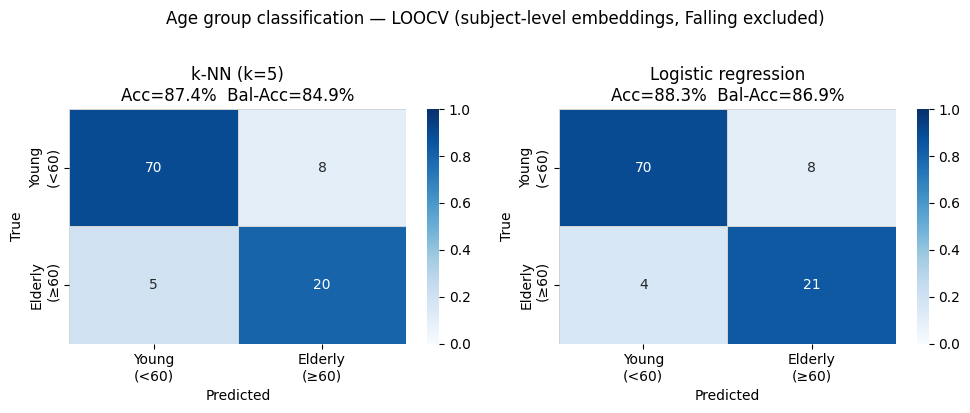

In [9]:
class_names = [f"Young\n(<{AGE_CUTOFF})", f"Elderly\n(≥{AGE_CUTOFF})"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, name in zip(
    axes,
    [knn_preds, lr_preds],
    [f"k-NN (k={KNN_K})", "Logistic regression"],
):
    cm = confusion_matrix(y_groups, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, ax=ax, annot=cm, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        vmin=0, vmax=1, linewidths=0.5, linecolor="lightgrey",
    )
    acc  = accuracy_score(y_groups, preds)
    bacc = balanced_accuracy_score(y_groups, preds)
    ax.set_title(f"{name}\nAcc={acc*100:.1f}%  Bal-Acc={bacc*100:.1f}%")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Age group classification — LOOCV (subject-level embeddings, Falling excluded)", y=1.02)
plt.tight_layout()
plt.savefig("glasgow_age_classification.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Misclassified subjects

In [10]:
group_label = {0: f"Young (<{AGE_CUTOFF})", 1: f"Elderly (≥{AGE_CUTOFF})"}

rows = []
for i, key in enumerate(subject_keys):
    row = meta[meta["subject_key"] == key].iloc[0]
    knn_ok = knn_preds[i] == y_groups[i]
    lr_ok  = lr_preds[i]  == y_groups[i]
    if not knn_ok or not lr_ok:
        rows.append({
            "subject":   key,
            "dataset":   int(row["dataset_id"]),
            "age":       int(row["age"]),
            "true":      group_label[y_groups[i]],
            "k-NN":      "✓" if knn_ok else f"→ {group_label[knn_preds[i]]}",
            "LR":        "✓" if lr_ok  else f"→ {group_label[lr_preds[i]]}",
            "dist_cutoff": abs(int(row["age"]) - AGE_CUTOFF),
        })

df_errors = pd.DataFrame(rows).sort_values("age")
print(f"{len(df_errors)} subjects misclassified by at least one model:\n")
print(df_errors.to_string(index=False))

19 subjects misclassified by at least one model:

subject  dataset  age          true            k-NN              LR  dist_cutoff
 D05P12        5   25   Young (<60) → Elderly (≥60)               ✓           35
 D01P52        1   26   Young (<60)               ✓ → Elderly (≥60)           34
 D05P15        5   27   Young (<60) → Elderly (≥60) → Elderly (≥60)           33
 D04P61        4   27   Young (<60)               ✓ → Elderly (≥60)           33
 D05P09        5   30   Young (<60) → Elderly (≥60)               ✓           30
 D05P13        5   31   Young (<60) → Elderly (≥60)               ✓           29
 D05P07        5   34   Young (<60) → Elderly (≥60)               ✓           26
 D07P44        7   45   Young (<60)               ✓ → Elderly (≥60)           15
 D07P51        7   50   Young (<60) → Elderly (≥60) → Elderly (≥60)           10
 D06P23        6   50   Young (<60)               ✓ → Elderly (≥60)           10
 D06P24        6   56   Young (<60) → Elderly (≥60) → Elder